# CosMx SMI 267T_not: REVISE sp-SVC

This compact, read-only case notebook audits the existing formal artifacts
and visualizes the single-cell reference, filtered raw CosMx data, and
reconstructed sp-SVC expression. It does not reconnect to a remote server,
rerun reconstruction, or modify the prepared data.

CosMx rows are segmented cells. In this user-selected application, sp-SVC
is interpreted as spatial-neighborhood expression reconstruction over those
cells, not as cell-subtype reconstruction.

Set `REVISE_COSMX_CASE_ROOT` to override the portable sibling-checkout data
location. The notebook deliberately displays only safe relative identities,
package versions, and hashes; source credentials and remote paths are never
rendered.


In [1]:
import contextlib
import hashlib
import importlib.metadata
import io
import json
import os
from pathlib import Path
import struct
import subprocess
import sys
from collections.abc import Mapping

for key in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
    "BLIS_NUM_THREADS", "TBB_NUM_THREADS",
):
    os.environ[key] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["MPLBACKEND"] = "Agg"
os.environ.pop("NUMBA_DISABLE_JIT", None)

import anndata as ad
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import revise

SEED = 42
MAX_UMAP_OBSERVATIONS = 10_000
EXPECTED_OUTPUT_SHAPE = (23_051, 6_042)


def locate_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "reconstruct.py").is_file() and (
            candidate / "reproduce/case/cosmx"
        ).is_dir():
            return candidate
    raise RuntimeError("Cannot locate the REVISE repository from the working directory")


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def hash_strings(values):
    digest = hashlib.sha256()
    for value in values:
        encoded = str(value).encode("utf-8")
        digest.update(struct.pack(">Q", len(encoded)))
        digest.update(encoded)
    return digest.hexdigest()


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def git_bytes(*arguments):
    return subprocess.run(
        ["git", *arguments],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
    ).stdout


REPO_ROOT = locate_repo_root()
TACCO_CASE_DIR = REPO_ROOT / "reproduce/case/tacco"
sys.path.insert(0, str(TACCO_CASE_DIR))

from notebook_utils import plot_independent_panels

default_case_root = (
    REPO_ROOT.parent
    / "REVISE_rebuttal/raw_data/Real_application/CosMx_SMI_267T_not"
)
CASE_ROOT = Path(
    os.environ.get("REVISE_COSMX_CASE_ROOT", str(default_case_root))
).expanduser().resolve()
if not CASE_ROOT.is_dir():
    raise FileNotFoundError(
        "CosMx case data are unavailable; set REVISE_COSMX_CASE_ROOT to the case directory"
    )

relative_artifacts = {
    "prepared ST": Path("prepared/CosMx_SMI_267T_not_ST.h5ad"),
    "panel-aligned reference": Path(
        "prepared/sc_downsampled_deconvST_REVISE_panel6042.h5ad"
    ),
    "formal sp-SVC": Path(
        "results/CosMx_SMI_267T_not/CosMx_SMI_267T_not_sp_SVC.h5ad"
    ),
    "source manifest": Path("manifests/source_manifest.json"),
    "dry-run report": Path("provenance/dry_run_validation.json"),
    "validation report": Path("provenance/validation_report.json"),
    "formal source state": Path("provenance/source_state.json"),
    "formal config": Path("configs/CosMx_SMI_267T_not_sp_SVC.yaml"),
}
missing = [name for name, relative in relative_artifacts.items() if not (CASE_ROOT / relative).is_file()]
if missing:
    raise FileNotFoundError("Missing required CosMx artifacts: " + ", ".join(missing))

ST_PATH = CASE_ROOT / relative_artifacts["prepared ST"]
REFERENCE_PATH = CASE_ROOT / relative_artifacts["panel-aligned reference"]
SVC_PATH = CASE_ROOT / relative_artifacts["formal sp-SVC"]
SOURCE_MANIFEST_PATH = CASE_ROOT / relative_artifacts["source manifest"]
DRY_REPORT_PATH = CASE_ROOT / relative_artifacts["dry-run report"]
VALIDATION_REPORT_PATH = CASE_ROOT / relative_artifacts["validation report"]
SOURCE_STATE_PATH = CASE_ROOT / relative_artifacts["formal source state"]
CONFIG_PATH = CASE_ROOT / relative_artifacts["formal config"]

source_manifest = load_json(SOURCE_MANIFEST_PATH)
dry_report = load_json(DRY_REPORT_PATH)
validation_report = load_json(VALIDATION_REPORT_PATH)
formal_source_state = load_json(SOURCE_STATE_PATH)

runtime_versions = {
    "Python": sys.version.split()[0],
    "REVISE": importlib.metadata.version("revise-svc"),
    "TACCO": importlib.metadata.version("tacco"),
    "Scanpy": importlib.metadata.version("scanpy"),
    "Squidpy": importlib.metadata.version("squidpy"),
}
assert runtime_versions == {
    "Python": "3.10.14",
    "REVISE": "0.1.0",
    "TACCO": "0.5.0",
    "Scanpy": "1.11.4",
    "Squidpy": "1.6.3",
}
thread_environment = {
    key: os.environ[key]
    for key in (
        "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
        "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
        "BLIS_NUM_THREADS", "TBB_NUM_THREADS",
    )
}
assert set(thread_environment.values()) == {"1"}

revise_file = Path(revise.__file__).resolve()
try:
    revise_relative = revise_file.relative_to(REPO_ROOT).as_posix()
except ValueError as error:
    raise RuntimeError("The notebook imported REVISE from outside this checkout") from error
assert revise_relative == "revise/__init__.py"

current_head = git_bytes("rev-parse", "HEAD").decode().strip()
status_lines = git_bytes("status", "--porcelain=v1", "--untracked-files=all").decode().splitlines()
tracked_diff_sha256 = hashlib.sha256(git_bytes("diff", "--binary", "HEAD", "--")).hexdigest()

display(pd.DataFrame(runtime_versions.items(), columns=["runtime", "version"]))
display(pd.DataFrame(thread_environment.items(), columns=["thread variable", "value"]))
display(pd.DataFrame([
    {
        "source snapshot": "formal reconstruction",
        "HEAD": formal_source_state["repository"]["head"],
        "dirty": bool(formal_source_state["repository"]["status_porcelain"]),
        "tracked diff SHA256": formal_source_state["repository"]["tracked_diff_sha256"],
        "REVISE import": "revise/__init__.py",
    },
    {
        "source snapshot": "notebook display runtime",
        "HEAD": current_head,
        "dirty": bool(status_lines),
        "tracked diff SHA256": tracked_diff_sha256,
        "REVISE import": revise_relative,
    },
]))


,runtime,version
0,Python,3.10.14
1,REVISE,0.1.0
2,TACCO,0.5.0
3,Scanpy,1.11.4
4,Squidpy,1.6.3


,thread variable,value
0,OMP_NUM_THREADS,1
1,OPENBLAS_NUM_THREADS,1
2,MKL_NUM_THREADS,1
3,NUMEXPR_NUM_THREADS,1
4,VECLIB_MAXIMUM_THREADS,1
5,NUMBA_NUM_THREADS,1
6,BLIS_NUM_THREADS,1
7,TBB_NUM_THREADS,1


,source snapshot,HEAD,dirty,tracked diff SHA256,REVISE import
0,formal reconstruction,afe425d741cf366c1b65e3864df4f7e31b008fd4,True,d25b75c11dae8b4ac7c8eb82e6daaede0da7bc517c0e6b...,revise/__init__.py
1,notebook display runtime,afe425d741cf366c1b65e3864df4f7e31b008fd4,True,c267eb5d99757297fc2df93f4614036167ac7a49c5e0fa...,revise/__init__.py


## 1. Formal artifact and provenance audit

The prepared ST matrix retains the full 6,175-gene CosMx panel. The reference
retains all 109,951 cells on the 6,042-gene ST-reference overlap. The formal
output must be sparse, finite, nonnegative, and exactly `(23,051, 6,042)`.

The formal publication contains the same filtered ST cell set but has a
different row order. This notebook verifies that fact and explicitly aligns
raw ST to the formal output's `obs_names` before using Global Anchoring labels.


In [2]:
def audit_backed_matrix(name, adata, *, collect_row_sums=False, collect_col_nonzero=False):
    if getattr(adata.X, "format", None) != "csr":
        raise TypeError(f"{name}.X must be backed CSR")
    if not adata.obs_names.is_unique or not adata.var_names.is_unique:
        raise ValueError(f"{name} has duplicate observation or gene names")

    row_sums = np.empty(adata.n_obs, dtype=float) if collect_row_sums else None
    col_nonzero = np.zeros(adata.n_vars, dtype=np.int64) if collect_col_nonzero else None
    observed_nnz = 0
    for start in range(0, adata.n_obs, 2_048):
        end = min(start + 2_048, adata.n_obs)
        block = adata.X[start:end]
        if not sparse.isspmatrix_csr(block):
            raise TypeError(f"{name}.X yielded a non-CSR block")
        if not np.isfinite(block.data).all() or (block.data < 0).any():
            raise ValueError(f"{name}.X contains non-finite or negative values")
        observed_nnz += int(block.nnz)
        if row_sums is not None:
            row_sums[start:end] = np.asarray(block.sum(axis=1)).ravel()
        if col_nonzero is not None:
            col_nonzero += np.asarray(block.getnnz(axis=0)).ravel()

    return {
        "object": name,
        "n_obs": int(adata.n_obs),
        "n_vars": int(adata.n_vars),
        "format": "csr",
        "dtype": str(adata.X.dtype),
        "nnz": observed_nnz,
        "finite": True,
        "nonnegative": True,
        "unique obs": True,
        "unique vars": True,
    }, row_sums, col_nonzero


run_candidates = []
run_root = CASE_ROOT / "results/CosMx_SMI_267T_not/sp-SVC/application__sp-SVC"
for candidate in sorted(run_root.glob("*/provenance.json")):
    payload = load_json(candidate)
    run = payload.get("run", {})
    if run.get("status") == "succeeded" and run.get("dry_run") is False:
        run_candidates.append((candidate, payload))
if len(run_candidates) != 1:
    raise RuntimeError("Expected exactly one succeeded non-dry formal provenance record")
FORMAL_PROVENANCE_PATH, formal_provenance = run_candidates[0]
MERGED_CONFIG_PATH = FORMAL_PROVENANCE_PATH.parent / "merged_config.json"
merged_config = load_json(MERGED_CONFIG_PATH)

assert dry_report["status"] == "succeeded"
assert validation_report["status"] == "succeeded"
assert validation_report["inputs"]["source_manifest"]["sha256"] == sha256_file(SOURCE_MANIFEST_PATH)
assert validation_report["inputs"]["dry_run_report"]["sha256"] == sha256_file(DRY_REPORT_PATH)
assert validation_report["inputs"]["source_state"]["sha256"] == sha256_file(SOURCE_STATE_PATH)
assert validation_report["formal_run"]["manifest_sha256"] == sha256_file(FORMAL_PROVENANCE_PATH)
assert validation_report["formal_run"]["merged_config_sha256"] == sha256_file(MERGED_CONFIG_PATH)

artifact_hashes = {
    "prepared ST": sha256_file(ST_PATH),
    "panel-aligned reference": sha256_file(REFERENCE_PATH),
    "formal sp-SVC": sha256_file(SVC_PATH),
    "formal config": sha256_file(CONFIG_PATH),
}
assert artifact_hashes["prepared ST"] == source_manifest["outputs"]["st"]["sha256"]
assert artifact_hashes["panel-aligned reference"] == source_manifest["outputs"]["sc"]["sha256"]
assert artifact_hashes["formal sp-SVC"] == validation_report["output"]["sha256"]
assert artifact_hashes["formal config"] == formal_provenance["application_config"]["source_sha256"]

st_backed = ad.read_h5ad(ST_PATH, backed="r")
reference_backed = ad.read_h5ad(REFERENCE_PATH, backed="r")
svc_backed = ad.read_h5ad(SVC_PATH, backed="r")

st_audit, st_row_sums, _ = audit_backed_matrix(
    "prepared ST", st_backed, collect_row_sums=True
)
reference_audit, _, reference_col_nonzero = audit_backed_matrix(
    "panel-aligned reference", reference_backed, collect_col_nonzero=True
)
svc_audit, _, _ = audit_backed_matrix("formal sp-SVC", svc_backed)

assert st_backed.shape == (23_119, 6_175)
assert reference_backed.shape == (109_951, 6_042)
assert svc_backed.shape == EXPECTED_OUTPUT_SHAPE
assert source_manifest["gene_contract"]["st_panel_genes"] == 6_175
assert source_manifest["gene_contract"]["exact_overlap_genes"] == 6_042
assert source_manifest["selection"]["expected_cells_after_min_counts_50"] == 23_051

cell_mask = st_row_sums >= 50
expected_obs_names = st_backed.obs_names[cell_mask]
expected_var_names = st_backed.var_names.intersection(
    reference_backed.var_names, sort=False
)
assert len(expected_obs_names) == EXPECTED_OUTPUT_SHAPE[0]
assert expected_var_names.equals(reference_backed.var_names)
assert len(expected_var_names) == EXPECTED_OUTPUT_SHAPE[1]
assert set(svc_backed.obs_names) == set(expected_obs_names)
assert svc_backed.var_names.equals(expected_var_names)
assert hash_strings(expected_obs_names) == dry_report["formal_contract"]["expected_obs_names_sha256"]
assert hash_strings(svc_backed.var_names) == dry_report["formal_contract"]["expected_var_names_sha256"]

# The formal publication contains the correct cell set but reorders its rows.
# Raw ST is therefore aligned explicitly to the publication order before use.
output_order_matches_filtered_st = svc_backed.obs_names.equals(expected_obs_names)
assert output_order_matches_filtered_st is False
assert validation_report["output"]["cell_order_matches_filtered_st"] is False
raw_aligned_obs_names = st_backed.obs.loc[svc_backed.obs_names].index
assert raw_aligned_obs_names.equals(svc_backed.obs_names)

common_positions = st_backed.var_names.get_indexer(expected_var_names)
assert (common_positions >= 0).all()
st_common_nonzero = np.zeros(len(expected_var_names), dtype=np.int64)
for start in range(0, st_backed.n_obs, 2_048):
    end = min(start + 2_048, st_backed.n_obs)
    selected = st_backed.X[start:end][cell_mask[start:end], :][:, common_positions]
    st_common_nonzero += np.asarray(selected.getnnz(axis=0)).ravel()
assert (st_common_nonzero >= 1).all()
assert (reference_col_nonzero >= 1).all()

for name, spatial in (
    ("prepared ST", st_backed.obsm["spatial"]),
    ("formal sp-SVC", svc_backed.obsm["spatial"]),
):
    values = np.asarray(spatial, dtype=float)
    if values.shape[1] != 2 or not np.isfinite(values).all():
        raise ValueError(f"{name} has invalid spatial coordinates")

if "Major.type" not in svc_backed.obs:
    raise KeyError("Formal output does not preserve Major.type")
expected_major = st_backed.obs.loc[svc_backed.obs_names, "Major.type"].astype(str)
observed_major = svc_backed.obs["Major.type"].astype(str)
assert np.array_equal(expected_major.to_numpy(), observed_major.to_numpy())
if "Level1" not in svc_backed.obs or "Level1" not in svc_backed.obsm:
    raise KeyError("Formal output must contain Level1 in both obs and obsm")
if svc_backed.obs["Level1"].isna().any():
    raise ValueError("Formal Level1 assignments are incomplete")
posterior = svc_backed.obsm["Level1"]
posterior_values = (
    posterior.to_numpy(dtype=float)
    if isinstance(posterior, pd.DataFrame)
    else np.asarray(posterior, dtype=float)
)
assert posterior_values.shape == (23_051, 11)
assert np.isfinite(posterior_values).all() and (posterior_values >= 0).all()
assert "Level1" in reference_backed.obs
reference_level1 = (
    reference_backed.obs["Level1"]
    .astype(str)
    .str.replace("/", "_", regex=False)
    .replace({"Epi": "Epithelial"})
)
assert reference_level1.notna().all()
assert "Epi" not in set(reference_level1)
assert not any("/" in label for label in reference_level1)

run = formal_provenance["run"]
assert run["status"] == "succeeded" and run["dry_run"] is False and run["error"] is None
assert formal_provenance["packages"]["Python"] == "3.10.14"
assert formal_provenance["packages"]["tacco"] == "0.5.0"
assert formal_provenance["runtime_seed"] == SEED
assert formal_provenance["ot_config"]["ga"]["solver"] == "tacco"
assert formal_provenance["ot_config"]["lr"]["solver"] == "tacco"
assert formal_provenance["local_refinement"] == {
    "route": "application:sp-SVC",
    "applied": True,
    "strength": 0.0,
}
expected_graph = {
    "method": "joint",
    "alpha": 0.8,
    "n_neighbors": 10,
    "exp_neighbors": 10,
    "spatial_neighbors": 6,
}
assert {key: merged_config["graph"][key] for key in expected_graph} == expected_graph
effective_request = formal_provenance["application_config"]["effective_request"]
assert effective_request["svc_type"] == "sp-SVC"
assert effective_request["algorithm"] == {"ot_method": "tacco"}
assert effective_request["preprocessing"] == {
    "spatial": {
        "min_transcript_counts": None,
        "min_counts": 50,
        "min_cell_counts": 1,
    },
    "reference": {
        "min_transcript_counts": None,
        "min_genes": None,
        "min_cell_counts": 1,
    },
}
assert effective_request["global_anchoring"] == {"broad_column": "Level1"}
assert effective_request["local_refinement"] == {
    "strength": 0.0,
    "graph": expected_graph,
}
assert effective_request["execution"] == {"seed": 42}

stage_status = {
    stage["name"]: stage["status"] for stage in formal_provenance["stages"]
}
assert stage_status == {
    "validate_inputs": "succeeded",
    "global_anchoring": "succeeded",
    "local_refinement": "succeeded",
    "finalize": "succeeded",
    "evaluate": "skipped",
}
publication = next(
    item
    for item in formal_provenance["artifacts"]
    if item.get("role") == "publication:svc"
)
assert publication["status"] == "completed"
assert publication["size"] == SVC_PATH.stat().st_size
assert publication["sha256"] == artifact_hashes["formal sp-SVC"]
embedded = svc_backed.uns.get("revise_reconstruction")
assert isinstance(embedded, Mapping)
assert embedded["output_role"] == "svc"
assert Path(str(embedded["run_manifest"])).parent.name == FORMAL_PROVENANCE_PATH.parent.name

display(pd.DataFrame([st_audit, reference_audit, svc_audit]))
display(pd.DataFrame([
    {
        "contract": "filtered ST cells",
        "result": f"{len(expected_obs_names):,}",
    },
    {
        "contract": "formal shared genes in fixed order",
        "result": f"{len(expected_var_names):,}",
    },
    {
        "contract": "formal output cell set matches filtered ST",
        "result": True,
    },
    {
        "contract": "raw ST explicitly reindexed to formal output order",
        "result": raw_aligned_obs_names.equals(svc_backed.obs_names),
    },
    {
        "contract": "formal output gene identity and order match",
        "result": svc_backed.var_names.equals(expected_var_names),
    },
]))
display(pd.DataFrame([
    {
        "formal status": run["status"],
        "dry run": run["dry_run"],
        "TACCO": formal_provenance["packages"]["tacco"],
        "seed": formal_provenance["runtime_seed"],
        "graph alpha": merged_config["graph"]["alpha"],
        "TopK": merged_config["graph"]["n_neighbors"],
        "expression neighbors": merged_config["graph"]["exp_neighbors"],
        "spatial neighbors": merged_config["graph"]["spatial_neighbors"],
        "Local Refinement applied": formal_provenance["local_refinement"]["applied"],
        "strength": formal_provenance["local_refinement"]["strength"],
        "duration seconds": run["duration_seconds"],
        "peak RSS GiB": validation_report["formal_run"]["resource_usage"][
            "maximum_resident_set_size_gib"
        ],
        "output SHA256": artifact_hashes["formal sp-SVC"],
    }
]))
display(pd.DataFrame(
    formal_provenance["stages"]
)[["name", "owner", "status", "duration_seconds", "reason"]])
print("Artifact, matrix, alignment, and formal provenance audit passed.")


,object,n_obs,n_vars,format,dtype,nnz,finite,nonnegative,unique obs,unique vars
0,prepared ST,23119,6175,csr,float64,29839750,True,True,True,True
1,panel-aligned reference,109951,6042,csr,int64,70777440,True,True,True,True
2,formal sp-SVC,23051,6042,csr,float64,85973671,True,True,True,True


,contract,result
0,filtered ST cells,"23,051"
1,formal shared genes in fixed order,"6,042"
2,formal output cell set matches filtered ST,True
3,raw ST explicitly reindexed to formal output o...,True
4,formal output gene identity and order match,True


,formal status,dry run,TACCO,seed,graph alpha,TopK,expression neighbors,spatial neighbors,Local Refinement applied,strength,duration seconds,peak RSS GiB,output SHA256
0,succeeded,False,0.5.0,42,0.8,10,10,6,True,0.0,61.934942,3.471954,acf571188e4292b52a5f0653f6b6e87e733eadb7b39c3b...


,name,owner,status,duration_seconds,reason
0,validate_inputs,pipeline.validate_inputs,succeeded,0.864117,None
1,global_anchoring,strategy.global_anchoring,succeeded,13.035457,None
2,local_refinement,strategy.local_refinement,succeeded,46.687956,None
3,finalize,pipeline.finalize,succeeded,1.336732,None
4,evaluate,pipeline.evaluate,skipped,NaN,policy_disabled


Artifact, matrix, alignment, and formal provenance audit passed.


## 2. Independently fitted expression-space UMAPs

Each panel uses at most 10,000 deterministically selected observations and
independently applies total-count normalization, log transformation, up to
2,000 highly variable genes, PCA, a 15-neighbor graph, and UMAP with seed 42.

The reference is colored by normalized `Level1`. Raw filtered ST is colored
by the formal Global Anchoring `Level1` after explicit `obs_names` alignment.
The reconstructed panel is colored by output `Level1`.


,source,input observations,sampled observations,input genes,genes after HVG,PCs,neighbors,seed
0,reference,10000,10000,6042,2000,30,15,42
1,raw_st,10000,10000,6042,2000,30,15,42
2,svc,10000,10000,6042,2000,30,15,42


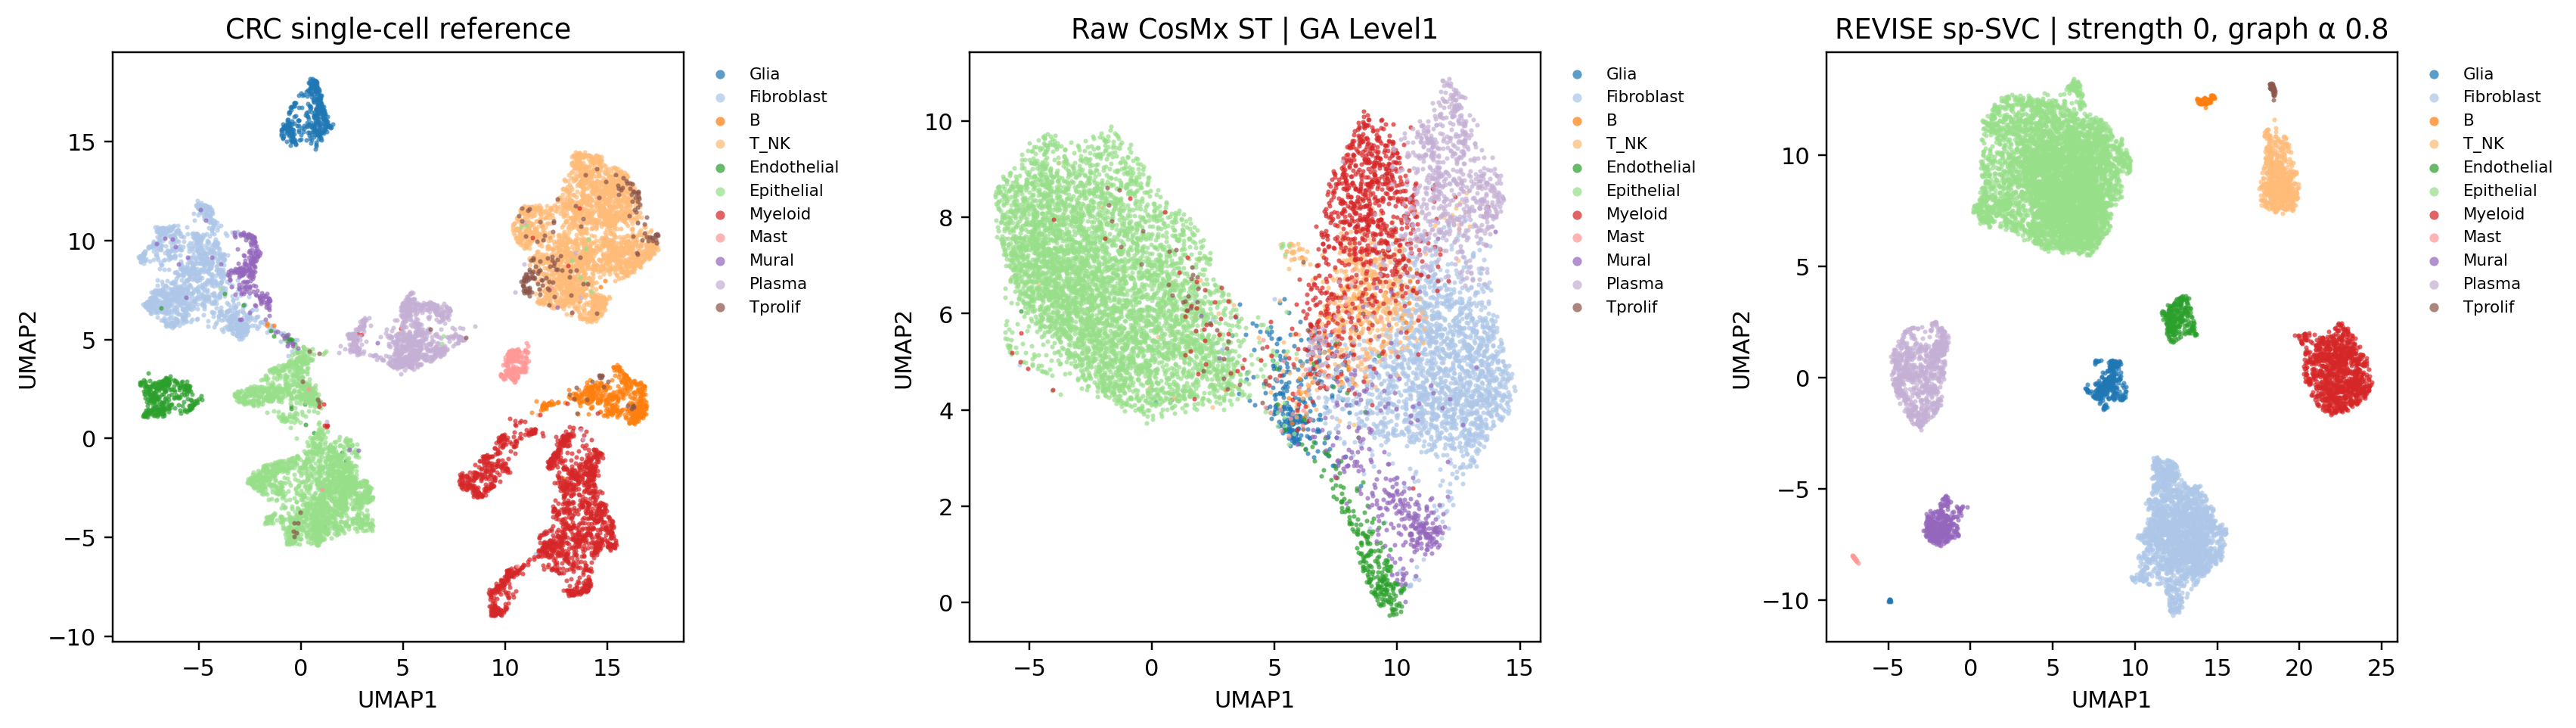

In [3]:
def sample_positions(n_obs, *, seed=SEED, maximum=MAX_UMAP_OBSERVATIONS):
    if n_obs <= maximum:
        return np.arange(n_obs, dtype=int)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_obs, size=maximum, replace=False))


def normalize_level1_labels(values):
    return (
        pd.Series(values, index=values.index)
        .astype(str)
        .str.replace("/", "_", regex=False)
        .replace({"Epi": "Epithelial"})
    )


def fit_independent_umap(adata, labels, source_name):
    labels = pd.Series(np.asarray(labels, dtype=str), index=adata.obs_names)
    if len(labels) != adata.n_obs or labels.isna().any():
        raise ValueError(f"Invalid display labels for {source_name}")
    prepared = ad.AnnData(
        X=adata.X.copy(),
        obs=pd.DataFrame({"_display_label": labels}, index=adata.obs_names.copy()),
        var=pd.DataFrame(index=adata.var_names.copy()),
    )
    input_shape = prepared.shape
    sc.pp.normalize_total(prepared, target_sum=1e4)
    sc.pp.log1p(prepared)
    n_top = min(2_000, prepared.n_vars)
    if n_top < prepared.n_vars:
        sc.pp.highly_variable_genes(prepared, n_top_genes=n_top, subset=True)
    n_comps = min(30, prepared.n_obs - 1, prepared.n_vars - 1)
    sc.pp.pca(prepared, n_comps=n_comps, random_state=SEED)
    n_neighbors = min(15, prepared.n_obs - 1)
    sc.pp.neighbors(
        prepared,
        n_neighbors=n_neighbors,
        n_pcs=n_comps,
        random_state=SEED,
    )
    sc.tl.umap(prepared, random_state=SEED)
    prepared.uns["independent_umap_contract"] = {
        "source": source_name,
        "input observations": int(input_shape[0]),
        "sampled observations": int(prepared.n_obs),
        "input genes": int(input_shape[1]),
        "genes after HVG": int(prepared.n_vars),
        "PCs": int(n_comps),
        "neighbors": int(n_neighbors),
        "seed": SEED,
    }
    return prepared


reference_positions = sample_positions(reference_backed.n_obs, seed=SEED)
paired_positions = sample_positions(svc_backed.n_obs, seed=SEED)
paired_obs_names = svc_backed.obs_names[paired_positions]

reference_sample = reference_backed[reference_positions, :].to_memory()
svc_sample = svc_backed[paired_positions, :].to_memory()
raw_sample = st_backed[paired_obs_names, expected_var_names].to_memory()
assert raw_sample.obs_names.equals(svc_sample.obs_names)
assert raw_sample.var_names.equals(svc_sample.var_names)

reference_labels = normalize_level1_labels(reference_sample.obs["Level1"])
formal_ga_level1 = normalize_level1_labels(
    svc_backed.obs["Level1"].reindex(raw_sample.obs_names)
)
svc_labels = normalize_level1_labels(svc_sample.obs["Level1"])
assert formal_ga_level1.notna().all()
assert np.array_equal(formal_ga_level1.to_numpy(), svc_labels.to_numpy())

for backed in (st_backed, reference_backed, svc_backed):
    backed.file.close()

sources = {
    "reference": (reference_sample, reference_labels),
    "raw_st": (raw_sample, formal_ga_level1),
    "svc": (svc_sample, svc_labels),
}
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    embeddings = {
        source: fit_independent_umap(adata, labels, source)
        for source, (adata, labels) in sources.items()
    }
contracts = pd.DataFrame([
    embeddings[source].uns["independent_umap_contract"]
    for source in ("reference", "raw_st", "svc")
])
assert (contracts["sampled observations"] <= MAX_UMAP_OBSERVATIONS).all()
assert set(contracts["seed"]) == {42}
display(contracts)

fig = plot_independent_panels(
    embeddings,
    ["reference", "raw_st", "svc"],
    titles={
        "reference": "CRC single-cell reference",
        "raw_st": "Raw CosMx ST | GA Level1",
        "svc": "REVISE sp-SVC | strength 0, graph α 0.8",
    },
)

buffer = io.BytesIO()
fig.savefig(buffer, format="png", dpi=220, bbox_inches="tight", facecolor="white")
png_bytes = buffer.getvalue()
assert png_bytes.startswith(b"\x89PNG\r\n\x1a\n") and len(png_bytes) > 100_000
display(Image(data=png_bytes))
plt.close(fig)


## Interpretation boundary

These are three separate within-source embeddings. Their coordinates,
orientation, scale, and distances are not comparable across panels. Colors
in the raw-ST panel are formal Global Anchoring assignments, not independent
raw annotations, and the display is descriptive rather than an independent
biological validation. Original `Major.type` is retained only for descriptive
comparison and is not a success threshold.

The reconstructed matrix is presented as spatial-neighborhood expression
reconstruction over segmented CosMx cells; it is not evidence of newly
resolved cell subtypes.
